In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        confusion_matrix,
        roc_curve,
        auc
)

In [8]:
data = load_breast_cancer()
X = data.data
y = data.target

print("Dataset Shape:", X.shape)
print("Classes:", np.unique(y))


Dataset Shape: (569, 30)
Classes: [0 1]


In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state = 42, stratify = y)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test =  scaler.transform(X_test)

In [18]:
mle_model = LogisticRegression(
            penalty=None,
            max_iter=5000,
            random_state=42
)
mle_model.fit(X_train, y_train)
y_pred_mle = mle_model.predict(X_test)

In [20]:
map_l2 = LogisticRegression(
    penalty='l2',
    C=1.0,
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)
map_l2.fit(X_train,y_train)
y_pred_l2 = map_l2.predict(X_test)

    

In [25]:
map_l1 = LogisticRegression(
         penalty='l1',
         C=1.0,
         solver = 'liblinear',
         max_iter=5000,
         random_state=42
)
map_l1.fit(X_train,y_train)
y_pred_l1 = map_l1.predict(X_test)

In [28]:
def evaluate(model_name, y_true,y_pred):
    print("\n", "="*40)
    print(model_name)
    print("="*40)
    print("Accuracy :",accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true,y_pred))
    print("Recall:", recall_score(y_true,y_pred))
    print("F1 Score:", f1_score(y_true, y_pred))

    print("\n Confusion Matrix")
    print(confusion_matrix(y_true,y_pred))


In [32]:
evaluate("MLE" , y_test,y_pred_mle)
evaluate("MAP L2", y_test,y_pred_l2)
evaluate("MAP L1", y_test, y_pred_l1)


MLE
Accuracy : 0.9210526315789473
Precision: 0.9701492537313433
Recall: 0.9027777777777778
F1 Score: 0.935251798561151

 Confusion Matrix
[[40  2]
 [ 7 65]]

MAP L2
Accuracy : 0.9824561403508771
Precision: 0.9861111111111112
Recall: 0.9861111111111112
F1 Score: 0.9861111111111112

 Confusion Matrix
[[41  1]
 [ 1 71]]

MAP L1
Accuracy : 0.9912280701754386
Precision: 0.9863013698630136
Recall: 1.0
F1 Score: 0.993103448275862

 Confusion Matrix
[[41  1]
 [ 0 72]]


In [35]:
print("Number of Zero coefficients")
print("MLE   :", np.sum(mle_model.coef_[0] == 0))
print("MAP L2 :", np.sum(map_l2.coef_[0] == 0))
print("MAP L1 :", np.sum(map_l1.coef_[0] == 0))

Number of Zero coefficients
MLE   : 0
MAP L2 : 0
MAP L1 : 14


In [38]:
results = pd.DataFrame(columns=[
        "Model",
       "Accuracy",
       "Precision",
      "Recall",
      "F1 Score"
])
models = [
    ("MLE", mle_model, y_pred_mle),
    ("MAP L2", map_l2 ,y_pred_l2),
    ("MAP L1", map_l1, y_pred_l1)
]
for name,model,pred in models:
    results.loc[len(results)] =[
        name, accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred)
    ]
print(results)

    Model  Accuracy  Precision    Recall  F1 Score
0     MLE  0.921053   0.970149  0.902778  0.935252
1  MAP L2  0.982456   0.986111  0.986111  0.986111
2  MAP L1  0.991228   0.986301  1.000000  0.993103


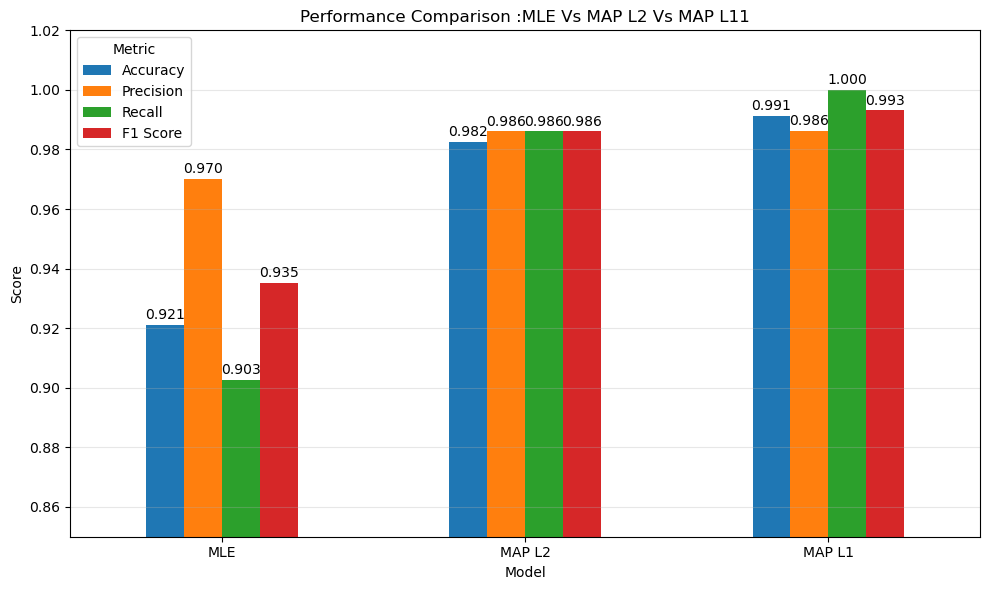

In [45]:
ax = results.set_index("Model").plot(
     kind="bar",
    figsize=(10,6)
)
plt.title("Performance Comparison :MLE Vs MAP L2 Vs MAP L11")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85,1.02)

plt.xticks(rotation =0)
plt.legend(title="Metric")
plt.grid(axis="y", alpha=0.3)
for container in ax.containers:
     ax.bar_label(container , fmt="%.3f", padding =2)

plt.tight_layout()


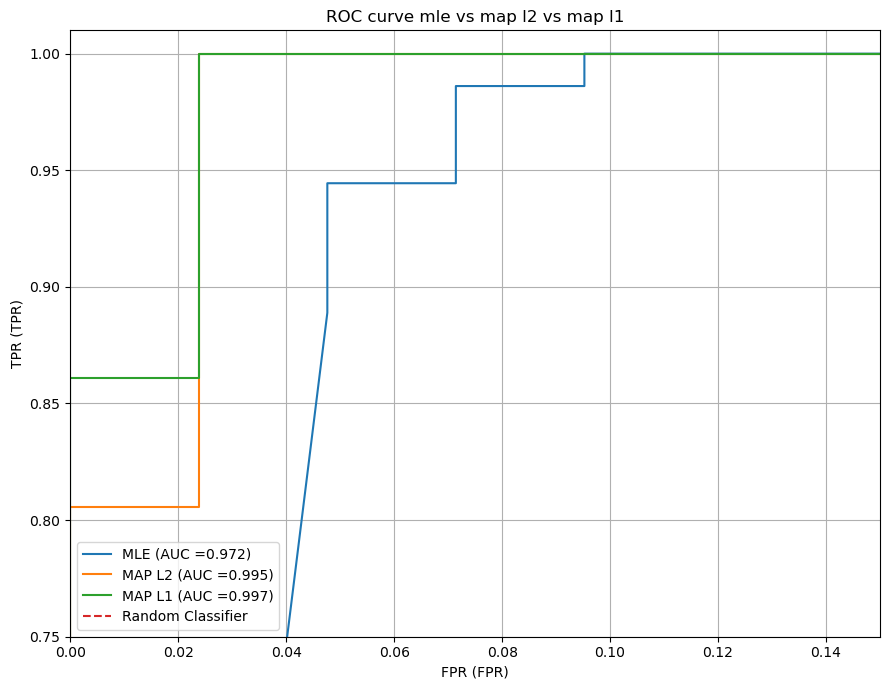

In [55]:
plt.figure(figsize=(9,7))

for name, model, pred in models:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr,tpr,thresholds = roc_curve(y_test,y_prob)
   #calculating auc
    roc_auc = auc(fpr,tpr)
    #plotting roc 
    plt.plot(
    fpr,
    tpr,label=f"{name} (AUC ={roc_auc:.3f})"
    )

plt.plot([0,1],
         [0,1],
         linestyle="--",
         label="Random Classifier"
)

plt.xlim(0,0.15)
plt.ylim(0.75,1.01)
plt.xlabel("FPR (FPR)")
plt.ylabel("TPR (TPR)")
plt.title("ROC curve mle vs map l2 vs map l1")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
    